# [종합 실습] 데이터 분석 개요 및 기초통계 (statsmodels 기반)

중고 자동차의 사양 및 거래 정보(연도, 신차가격, 주행거리, 연료 종류 등)를 활용하여 실제 판매 가격(Selling_Price)을 예측하는 선형회귀(OLS: Ordinary Least Squares) 모델을 구축한다.

**머신러닝 파이프라인**

데이터 로드 → 탐색적 데이터 분석(EDA) → 전처리 → statsmodels 기반 모델링 및 성능 평가

## 0. 환경 설정 (한글 폰트 및 패키지 불러오기)

한글 깨짐 방지

In [49]:
# ==============================================================================
# 1. 한글 폰트 설치 및 패키지 불러오기 (한글 깨짐 완벽 방지)
# ==============================================================================
!apt-get install -y fonts-nanum > /dev/null 2>&1
!fc-cache -fv > /dev/null 2>&1

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns

# 나눔고딕 폰트 지정
font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
font_prop = fm.FontProperties(fname=font_path)
plt.rc('font', family='NanumGothic')
plt.rcParams['axes.unicode_minus'] = False   # 마이너스 기호 깨짐 방지

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_percentage_error
import statsmodels.api as sm

---
## [문제 1] 데이터 로드 및 분석 제외 변수 처리 (10점)

- 제시된 URL에서 중고차 데이터셋을 로드하고, 데이터의 상위 5개 행과 요약 통계량을 출력하세요.
- 분석 대상이 아닌 Car_Name(자동차 모델명) 컬럼을 데이터셋에서 제거하세요.

In [50]:
# ==============================================================================
# [문제 1] 데이터 로드 및 분석 제외 변수 처리
# ==============================================================================
url = "https://raw.githubusercontent.com/amankharwal/Website-data/master/car%20data.csv"
df = pd.read_csv(url)

print("=" * 60)
print("[문제 1] 데이터 로드 및 기초 탐색")
print("=" * 60)

print("\n1. 상위 5개 행: ")
display(df.head())

print("\n2. 요약 통계량: ")
display(df.describe())

# 분석 대상이 아닌 Car_Name(자동차 모델명) 컬럼 제거
df = df.drop(columns=['Car_Name'])

print("\n3. Car_Name 제거 후 컬럼:", df.columns.tolist())

[문제 1] 데이터 로드 및 기초 탐색

1. 상위 5개 행: 


,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0



2. 요약 통계량: 


,Year,Selling_Price,Present_Price,Kms_Driven,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.644115,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000



3. Car_Name 제거 후 컬럼: ['Year', 'Selling_Price', 'Present_Price', 'Kms_Driven', 'Fuel_Type', 'Seller_Type', 'Transmission', 'Owner']


---
## [문제 2] 탐색적 데이터 분석(EDA) 시각화 및 인사이트 작성
- matplotlib 또는 seaborn을 활용하여 아래 3가지 시각화 그래프를 생성하세요.
1) Target 변수(Selling_Price)의 분포를 확인하기 위한 히스토그램
2) 신차 가격(Present_Price)과 실제 판매 가격(Selling_Price)의 관계를 나타내는 산점도
3) 연료 종류(Fuel_Type)별 판매 가격(Selling_Price) 차이를 비교하기 위한 박스플롯
- 시각화 결과를 바탕으로 데이터의 주요 특징과 경향성에 대해 2~3줄로 인사이트를 서술하세요.



[문제 2] EDA 시각화 작성


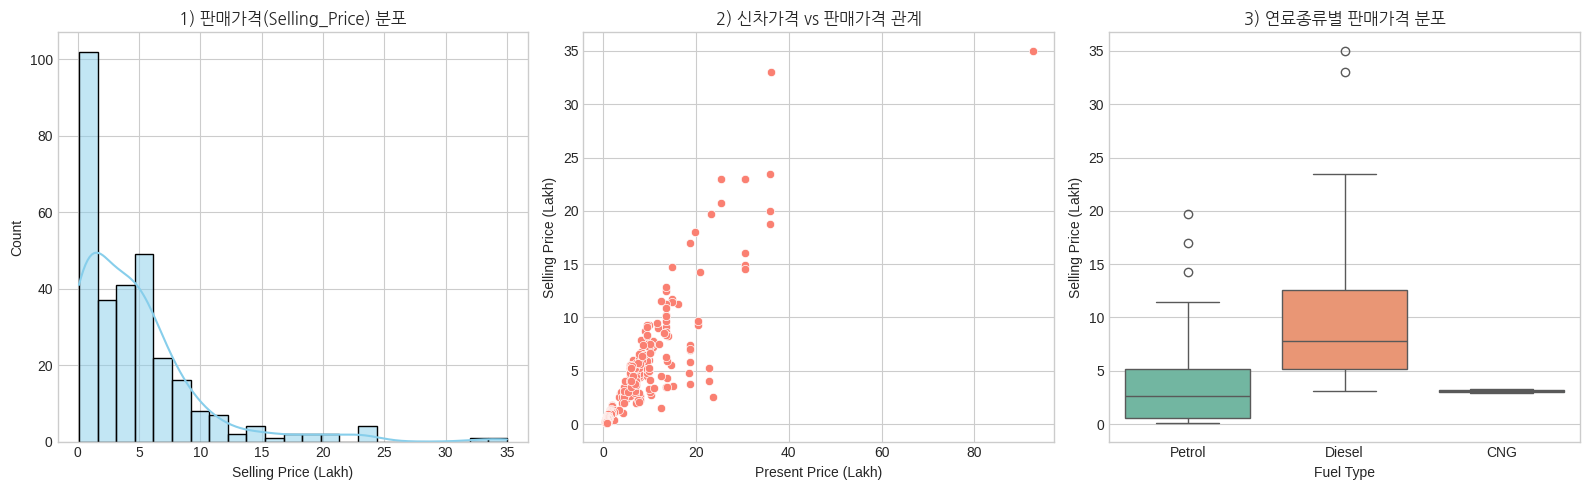

In [51]:
# ==============================================================================
# [문제 2] 탐색적 데이터 분석(EDA) 시각화 및 인사이트 작성
# ==============================================================================
print("\n" + "="*60)
print("[문제 2] EDA 시각화 작성")
print("="*60)

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1) Target 변수(Selling_Price) 히스토그램
sns.histplot(df['Selling_Price'], kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('1) 판매가격(Selling_Price) 분포', fontproperties=font_prop, fontsize=12)
axes[0].set_xlabel('Selling Price (Lakh)')
axes[0].set_ylabel('Count')

# 2) 신차가격(Present_Price)과 판매가격(Selling_Price) 산점도
sns.scatterplot(x='Present_Price', y='Selling_Price', data=df, ax=axes[1], color='salmon')
axes[1].set_title('2) 신차가격 vs 판매가격 관계', fontproperties=font_prop, fontsize=12)
axes[1].set_xlabel('Present Price (Lakh)')
axes[1].set_ylabel('Selling Price (Lakh)')

# 3) 연료종류(Fuel_Type)별 판매가격 박스플롯 (FutureWarning 방지를 위해 hue 지정)
sns.boxplot(x='Fuel_Type', y='Selling_Price', hue='Fuel_Type', data=df, ax=axes[2], palette='Set2', legend=False)
axes[2].set_title('3) 연료종류별 판매가격 분포', fontproperties=font_prop, fontsize=12)
axes[2].set_xlabel('Fuel Type')
axes[2].set_ylabel('Selling Price (Lakh)')

plt.tight_layout()
plt.show()


### EDA 인사이트 요약

1. 판매가격(Selling_Price)은 오른쪽으로 긴 꼬리를 갖는 비대칭 분포로, 대부분 0~10 Lakh 구간에 집중되어 있습니다.
2. 신차가격이 높아질수록 판매가격도 함께 증가하는 명확한 양(+)의 선형관계를 확인할 수 있습니다.
3. 연료종류별로는 Diesel 차량의 판매가격 중앙값이 Petrol보다 높게 형성되나, CNG는 표본이 매우 적어 해석에 주의가 필요합니다.

---
## [문제 3] 파생변수 생성 및 범주형 인코딩

- 차량 연식(Year) 정보를 활용하여 경과 연수(Vehicle_Age = 2026 - Year) 또는 차량 연차 관련 파생변수를 최소 1개 이상 신규 생성하세요.
- 범주형 변수(Fuel_Type, Seller_Type, Transmission 등)에 대해 pd.get_dummies()를 활용해 원-핫 인코딩을 수행하세요. (drop_first=True 적용)

In [52]:
# ==============================================================================
# [문제 3] 파생변수 생성 및 범주형 원-핫 인코딩
# ==============================================================================
print("\n" + "="*60)
print("[문제 3] 파생변수 생성 및 범주형 원-핫 인코딩")
print("="*60)

# 파생변수 생성: 차량 경과 연수
df['Vehicle_Age'] = 2026 - df['Year']

# Vehicle_Age = 2026 - Year 이므로 Year와 선형 종속 관계 → 상관계수 -1 확인 후 Year 제거
print("\nYear와 Vehicle_Age의 상관계수:", round(df['Year'].corr(df['Vehicle_Age']), 4))
df = df.drop(columns=['Year'])

# 원-핫 인코딩 (drop_first=True)
df_encoded = pd.get_dummies(df, columns=['Fuel_Type', 'Seller_Type', 'Transmission'],
                            drop_first=True, dtype=int)

print("\n인코딩 후 데이터 상위 5개 행:")
print(df_encoded.head())


[문제 3] 파생변수 생성 및 범주형 원-핫 인코딩

Year와 Vehicle_Age의 상관계수: -1.0

인코딩 후 데이터 상위 5개 행:
   Selling_Price  Present_Price  Kms_Driven  Owner  Vehicle_Age  \
0           3.35           5.59       27000      0           12   
1           4.75           9.54       43000      0           13   
2           7.25           9.85        6900      0            9   
3           2.85           4.15        5200      0           15   
4           4.60           6.87       42450      0           12   

   Fuel_Type_Diesel  Fuel_Type_Petrol  Seller_Type_Individual  \
0                 0                 1                       0   
1                 1                 0                       0   
2                 0                 1                       0   
3                 0                 1                       0   
4                 1                 0                       0   

   Transmission_Manual  
0                    1  
1                    1  
2                    1  
3                    1  


---
## [문제 4] 데이터 스케일링 및 비교 시각화

- 수치형 연속 변수(Present_Price, Kms_Driven, 파생변수 등)에 StandardScaler를 적용하세요.
- 스케일링 전과 후의 분포 변화를 Boxplot으로 비교 시각화하세요.


[문제 4] 데이터 스케일링 및 비교 시각화


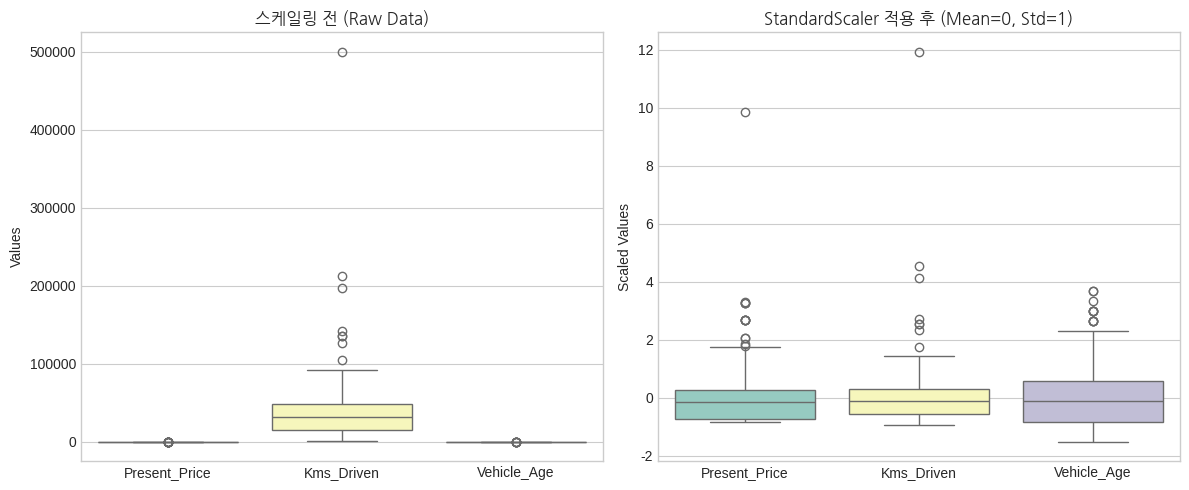

In [53]:
# ==============================================================================
# [문제 4] 데이터 스케일링 및 비교 시각화
# ==============================================================================
print("\n" + "="*60)
print("[문제 4] 데이터 스케일링 및 비교 시각화")
print("="*60)

scale_cols = ['Present_Price', 'Kms_Driven', 'Vehicle_Age']

# 스케일링 전 데이터 복사
X_before_scale = df_encoded[scale_cols].copy()

# StandardScaler 적용
scaler = StandardScaler()
X_after_scale = pd.DataFrame(
    scaler.fit_transform(X_before_scale),
    columns=scale_cols,
)

# 박스플롯 비교 시각화
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(data=X_before_scale, ax=axes[0], palette='Set3')
axes[0].set_title('스케일링 전 (Raw Data)', fontproperties=font_prop, fontsize=12)
axes[0].set_ylabel('Values')

sns.boxplot(data=X_after_scale, ax=axes[1], palette='Set3')
axes[1].set_title('StandardScaler 적용 후 (Mean=0, Std=1)', fontproperties=font_prop, fontsize=12)
axes[1].set_ylabel('Scaled Values')

plt.tight_layout()
plt.show()

# 스케일링 결과를 원본 데이터프레임에 반영
df_encoded[scale_cols] = X_after_scale

---
## [문제 5] 데이터 분할 및 상수항(절편) 추가

- 독립변수(X)와 Target 변수(y: Selling_Price)를 분리하세요.
- train_test_split을 사용하여 학습 데이터 7 : 테스트 데이터 3 비율로 분할하세요. (random_state=42, shuffle=True)
- statsmodels 적합을 위해 독립변수 데이터셋에 절편(상수항) const 컬럼을 추가하세요. (sm.add_constant() 활용)

In [54]:
# ==============================================================================
# [문제 5] 데이터 분할 및 statsmodels 전용 절편(const) 추가
# ==============================================================================
print("\n" + "="*60)
print("[문제 5] 독립변수/종속변수 분리 및 Train-Test 데이터 분할")
print("="*60)

X = df_encoded.drop(columns=['Selling_Price'])
y = df_encoded['Selling_Price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, shuffle=True
)

# statsmodels 절편(const) 추가
X_train_sm = sm.add_constant(X_train)
X_test_sm = sm.add_constant(X_test, has_constant='add')

print(f"학습 데이터 크기 (X_train_sm): {X_train_sm.shape}")
print(f"테스트 데이터 크기 (X_test_sm) : {X_test_sm.shape}")


[문제 5] 독립변수/종속변수 분리 및 Train-Test 데이터 분할
학습 데이터 크기 (X_train_sm): (210, 9)
테스트 데이터 크기 (X_test_sm) : (91, 9)


---
## [문제 6] statsmodels OLS 모델 학습 및 성능 평가

- statsmodels.api의 OLS 모델을 학습시키고, 회귀계수(Coefficients) 및 p-value 표를 출력하세요.
- 테스트 데이터 기준 결정계수(R²), RMSE 및 MAPE(Mean Absolute Percentage Error)를 산출해 모델의 예측 성능을 평가하세요.


In [55]:
# ==============================================================================
# [문제 6] statsmodels OLS 모델 학습 및 성능 평가
# ==============================================================================
print("\n" + "="*60)
print("[문제 6] statsmodels OLS 모델 학습 및 성능 평가")
print("="*60)

model = sm.OLS(y_train, X_train_sm).fit()

y_pred_train = model.predict(X_train_sm)
y_pred_test = model.predict(X_test_sm)

train_r2 = r2_score(y_train, y_pred_train)
test_r2 = r2_score(y_test, y_pred_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
mape = mean_absolute_percentage_error(y_test, y_pred_test) * 100

print(f"Train R² Score : {train_r2:.4f}")
print(f"Test R² Score  : {test_r2:.4f}")
print(f"Test RMSE      : {rmse:.4f} Lakh")
print(f"Test MAPE      : {mape:.2f} %")

coef_summary = pd.DataFrame({
    'Coefficient': model.params,
    'P-Value': model.pvalues
})
print("\n[주요 변수별 회귀계수 및 유의확률]")
print(coef_summary.round(4))


[문제 6] statsmodels OLS 모델 학습 및 성능 평가
Train R² Score : 0.8828
Test R² Score  : 0.8756
Test RMSE      : 1.8820 Lakh
Test MAPE      : 100.09 %

[주요 변수별 회귀계수 및 유의확률]
                        Coefficient  P-Value
const                        5.2936   0.0001
Present_Price                3.5986   0.0000
Kms_Driven                  -0.1723   0.1907
Owner                       -1.0303   0.0203
Vehicle_Age                 -1.0272   0.0000
Fuel_Type_Diesel             2.7118   0.0338
Fuel_Type_Petrol             0.7174   0.5636
Seller_Type_Individual      -1.1521   0.0001
Transmission_Manual         -1.4384   0.0006


---
## [문제 7] 신규 데이터 예측 및 최종 리포트 작성

- 신규 중고차 정보(예: 2018년식, 신차가격 10.0, 주행거리 30,000km, Petrol, Dealer, Manual)에 학습된 동일 전처리를 적용한 후 예상 판매 가격을 예측하여 출력하세요.
- 최종 선정된 모델의 주요 평가지표(MAPE) 및 결과를 서술하세요.


In [56]:
# ==============================================================================
# [문제 7] 신규 데이터 정확한 인코딩 매핑 및 판매가격 예측
# ==============================================================================
print("\n" + "="*60)
print("[문제 7] 신규 데이터 판매가격 예측")
print("="*60)

# 1. 신규 데이터 수동 인코딩 (X.columns 구조와 100% 일치하도록 구성)
# 조건: 2018년식 | Present_Price=10.0 | Kms_Driven=30000 | Petrol | Dealer | Manual
# drop_first=True 적용 기준:
# Fuel_Type_Petrol (Petrol이므로 1, 기준범주는 CNG)
# Seller_Type_Individual (Dealer이므로 0)
# Transmission_Manual (Manual이므로 1, 기준범주는 Automatic)

new_car_dict = {
    'Present_Price': 10.0,
    'Kms_Driven': 30000,
    'Owner': 0,
    'Vehicle_Age': 2026 - 2018,
    'Fuel_Type_Diesel': 0,
    'Fuel_Type_Petrol': 1,
    'Seller_Type_Individual': 0,
    'Transmission_Manual': 1
}

# X_train의 컬럼 순서 및 구성에 정확히 동기화
new_car_df = pd.DataFrame([new_car_dict])[X.columns]

# 2. 수치형 변수 스케일링
new_car_scaled = new_car_df.copy()
new_car_scaled[scale_cols] = scaler.transform(new_car_df[scale_cols])

# 3. statsmodels 전용 절편 추가 및 예측
new_car_sm = sm.add_constant(new_car_scaled, has_constant='add')
predicted_price = model.predict(new_car_sm).values[0]

print("신규 중고차 정보: 2018년식 | 신차가격 10.0 Lakh | 30,000km | Petrol | Dealer | Manual")
print(f"-> 예상 판매 가격: {predicted_price:.2f} Lakh")


[문제 7] 신규 데이터 판매가격 예측
신규 중고차 정보: 2018년식 | 신차가격 10.0 Lakh | 30,000km | Petrol | Dealer | Manual
-> 예상 판매 가격: 7.15 Lakh


### 최종 모델 리포트

**1. 최종 선정 모델**
다중 선형회귀(statsmodels OLS), 독립변수 8개 + 절편

**2. 모델 성능**
Train R² = 0.8828 / Test R² = 0.8756 (과적합 없이 판매가격 변동의 약 87.6% 설명)
Test RMSE = 1.8820 Lakh, Test MAPE = 100.09%

**3. MAPE 해석**
MAPE는 오차를 실제값으로 나누는 지표 특성상 실제값이 0에 가까울수록 오차율이 커지며,
요약 통계량상 Selling_Price는 최솟값 0.10 / 하위 25% 0.90 Lakh로 0에 근접한 값이 존재합니다.
따라서 MAPE 100.09%는 모델의 예측력보다 지표 특성이 반영된 값으로 판단되며,
본 데이터에서는 RMSE(1.8820 Lakh)를 주 평가지표로 해석하는 것이 타당합니다.

**4. 회귀계수 해석**

| 변수 | 계수 | p-value | 유의성 |
|---|---|---|---|
| Present_Price | 3.5986 | 0.0000 | 유의 |
| Vehicle_Age | -1.0272 | 0.0000 | 유의 |
| Transmission_Manual | -1.4384 | 0.0006 | 유의 |
| Seller_Type_Individual | -1.1521 | 0.0001 | 유의 |
| Owner | -1.0303 | 0.0203 | 유의 |
| Fuel_Type_Diesel | 2.7118 | 0.0338 | 유의 |
| Kms_Driven | -0.1723 | 0.1907 | 유의하지 않음 |
| Fuel_Type_Petrol | 0.7174 | 0.5636 | 유의하지 않음 |

신차가격이 높을수록 판매가가 상승하고, 연식이 오래되거나 수동변속기, 개인판매 혹은
소유이력이 많을수록 판매가가 하락하는 것으로 확인했습니다.

**5. 신규 중고차 예측 결과**
7.15 Lakh (신차가격 10.0 Lakh 대비 약 71.5% 수준)